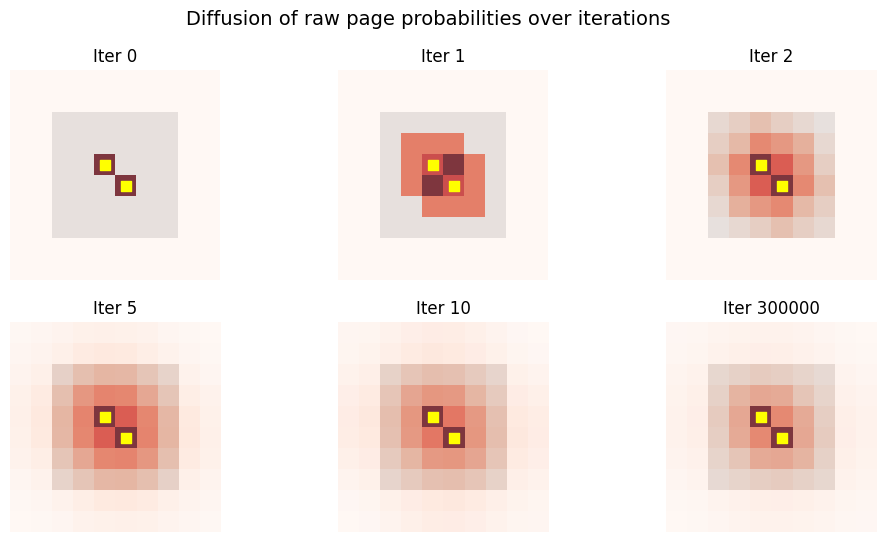

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Build Laplacian for grid graph (8-connected option)
def build_grid_laplacian(H, W, eight_connected=True):
    n = H * W
    def idx(r,c): return r*W + c
    edges = []
    for r in range(H):
        for c in range(W):
            u = idx(r,c)
            if r+1 < H: edges.append((u, idx(r+1,c)))
            if c+1 < W: edges.append((u, idx(r,c+1)))
            if eight_connected:
                if r+1 < H and c+1 < W: edges.append((u, idx(r+1,c+1)))
                if r+1 < H and c-1 >= 0: edges.append((u, idx(r+1,c-1)))
    A = np.zeros((n,n))
    for u,v in edges:
        A[u,v] = 1
        A[v,u] = 1
    D = np.diag(A.sum(axis=1))
    L = D - A
    return L, A

# Label propagation with clamping (binary case) - record iterations
def label_propagation_iterations(L, Y, alpha=0.95, max_iter=300):
    n, C = Y.shape
    F = Y.copy()
    # Build row-stochastic adjacency S = D^-1 A
    A = np.diag(np.diag(L)) - L
    D = np.diag(A.sum(axis=1))
    D_inv = np.zeros_like(D)
    for i in range(n):
        if D[i,i] > 0:
            D_inv[i,i] = 1.0 / D[i,i]
    S = D_inv @ A
    snapshots = [F.copy()]
    for _ in range(max_iter):
        F = alpha * (S @ F) + (1-alpha) * Y
        snapshots.append(F.copy())
    return snapshots

# Toy scanned doc (10x10 with white margins)
H, W = 10, 10
scanned = np.ones((H, W))
scanned[2:8, 2:8] = 0.7

# OCR token seeds: two points inside
ocr_seed_coords = [(4,4), (5,5)]
ocr_seeds = [r*W+c for r,c in ocr_seed_coords]
# Background seeds: borders
bg_seeds = [r*W+c for r in [0,H-1] for c in range(W)] + [r*W+c for r in range(H) for c in [0,W-1]]

# Build Y
n = H*W
C = 2
Y = np.zeros((n,C))
for idx in ocr_seeds:
    Y[idx,1] = 1
for idx in bg_seeds:
    Y[idx,0] = 1

# Run label propagation and get snapshots
L, A = build_grid_laplacian(H, W, eight_connected=True)
snapshots = label_propagation_iterations(L, Y, alpha=0.95, max_iter=300000)

# Visualize evolution (showing raw probabilities of 'page')
steps_to_show = [0, 1, 2, 5, 10, 300000]
plt.figure(figsize=(12,6))
for i, step in enumerate(steps_to_show):
    F = snapshots[step]
    page_prob = F[:,1].reshape(H,W)
    plt.subplot(2, len(steps_to_show)//2, i+1)
    plt.imshow(scanned, cmap="gray", vmin=0, vmax=1)
    plt.imshow(page_prob, cmap="Reds", alpha=0.7)  # auto-scaled colormap to show contrast
    plt.scatter([c for r,c in ocr_seed_coords], [r for r,c in ocr_seed_coords], 
                c='yellow', marker='s', s=60)
    plt.title(f"Iter {step}")
    plt.axis("off")

plt.suptitle("Diffusion of raw page probabilities over iterations", fontsize=14)
plt.show()


(-0.5, 9.5, 9.5, -0.5)

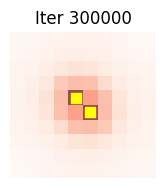

In [50]:
F = snapshots[-1]
page_prob = F[:,1].reshape(H,W)
plt.subplot(2, len(steps_to_show)//2, i+1)
# plt.imshow(scanned, cmap="gray", vmin=0, vmax=1)
plt.imshow(page_prob, cmap="Reds", alpha=0.7)  # auto-scaled colormap to show contrast
plt.scatter([c for r,c in ocr_seed_coords], [r for r,c in ocr_seed_coords], 
            c='yellow', marker='s', s=60)
plt.title(f"Iter {step}")
plt.axis("off")

In [53]:
page_prob

array([[0.0135622 , 0.01403307, 0.01512736, 0.01628961, 0.01692883,
        0.01669203, 0.01567368, 0.01432123, 0.01319947, 0.01274061],
       [0.01403307, 0.01476186, 0.01637378, 0.01815937, 0.01914543,
        0.01881268, 0.01729215, 0.015375  , 0.01383458, 0.01319947],
       [0.01512736, 0.01637378, 0.01967978, 0.02345961, 0.02591664,
        0.02496593, 0.02180784, 0.01796971, 0.015375  , 0.01432123],
       [0.01628961, 0.01815937, 0.02345961, 0.03497707, 0.03984295,
        0.03888233, 0.02853935, 0.02180784, 0.01729215, 0.01567368],
       [0.01692883, 0.01914543, 0.02591664, 0.03984295, 0.09642558,
        0.05104951, 0.03888233, 0.02496593, 0.01881268, 0.01669203],
       [0.01669203, 0.01881268, 0.02496593, 0.03888233, 0.05104951,
        0.09642558, 0.03984295, 0.02591664, 0.01914543, 0.01692883],
       [0.01567368, 0.01729215, 0.02180784, 0.02853935, 0.03888233,
        0.03984295, 0.03497707, 0.02345961, 0.01815937, 0.01628961],
       [0.01432123, 0.015375  , 0.0179697